In [1]:
import pandas as pd

In [2]:
import numpy as np

In [3]:
data=pd.read_csv("/content/Facebook 1.csv")

In [4]:
data.head()

,reviewId,content,score
0,5546a206-60b5-4854-92cd-c611e761ae03,so good 👍,5
1,dccc9bee-79e3-4c3f-877c-862270a4aa8d,nice ☺️,5
2,9d0b8e62-4d7d-49f7-a33a-c3f49c7e04ee,Eve CD sqwwxwxwxqwwww de w2w,4
3,3f81d8f0-2de1-41c4-8cea-e1513ffc7d41,Kashyap ji,5
4,f0f2f642-f874-423e-92ab-46774759bf6a,very nice,5


In [5]:
data.tail()

,reviewId,content,score
9995,60e3e950-d3dc-4b39-867f-95c74b31d6a8,ok op,5
9996,0dbee0c6-326f-4c02-8ed3-268b01e09573,Nice,5
9997,ffefa253-4749-4f6a-8cd8-61033f19bb76,go,5
9998,de8ba7f1-29fe-4b49-b9ab-2e9492cbaf17,nice,5
9999,e42a3e47-ebdd-42e2-9362-6d7a42dcfd43,Hi guys nice👍 Facebook,5


In [6]:
data.describe()

,score
count,10000.000000
mean,4.085200
std,1.506774
min,1.000000
25%,4.000000
50%,5.000000
75%,5.000000
max,5.000000


In [7]:
data.isnull().sum()

,0
reviewId,0
content,0
score,0


In [8]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   reviewId  10000 non-null  object
 1   content   10000 non-null  object
 2   score     10000 non-null  int64 
dtypes: int64(1), object(2)
memory usage: 234.5+ KB


Data cleaning

In [9]:
import re
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

In [10]:
nltk.download("punkt")
nltk.download("punkt_tab")
nltk.download("stopwords")

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [11]:
def preprocess_text(text):
  text=re.sub(r'[^\w\s]','',text) # removes punctuation \w it will check letters symbols \s -space or new line ,tab vagera ko remove kra that or ^notes in data
  text=text.lower()# converts text intolower
  text=word_tokenize(text) # vector m convert kr dega text ko
  text=[word for word in text if word not in stopwords.words('english')] # remove stopwords
  return ' '.join(text)

In [12]:
data['cleaned_content']=data['content'].apply(preprocess_text)
data.head()

,reviewId,content,score,cleaned_content
0,5546a206-60b5-4854-92cd-c611e761ae03,so good 👍,5,good
1,dccc9bee-79e3-4c3f-877c-862270a4aa8d,nice ☺️,5,nice
2,9d0b8e62-4d7d-49f7-a33a-c3f49c7e04ee,Eve CD sqwwxwxwxqwwww de w2w,4,eve cd sqwwxwxwxqwwww de w2w
3,3f81d8f0-2de1-41c4-8cea-e1513ffc7d41,Kashyap ji,5,kashyap ji
4,f0f2f642-f874-423e-92ab-46774759bf6a,very nice,5,nice


In [13]:
def label(score):
  if score >3:
    return "positive"
  elif score == 3:
    return "neutral"
  else :
    return "negative"

In [14]:
data["score_review"] = data["score"].apply(label)

In [15]:
data.head(50)

,reviewId,content,score,cleaned_content,score_review
0,5546a206-60b5-4854-92cd-c611e761ae03,so good 👍,5,good,positive
1,dccc9bee-79e3-4c3f-877c-862270a4aa8d,nice ☺️,5,nice,positive
2,9d0b8e62-4d7d-49f7-a33a-c3f49c7e04ee,Eve CD sqwwxwxwxqwwww de w2w,4,eve cd sqwwxwxwxqwwww de w2w,positive
3,3f81d8f0-2de1-41c4-8cea-e1513ffc7d41,Kashyap ji,5,kashyap ji,positive
4,f0f2f642-f874-423e-92ab-46774759bf6a,very nice,5,nice,positive
5,7028e390-d1e4-4636-97c9-01a0334b180e,follow me 😊,4,follow,positive
6,1f610c92-8ed5-47a4-8d91-bf804c643eb5,the best way to communicate with friends all o...,5,best way communicate friends places,positive
7,95112be6-a548-4d85-bbd2-682513d38f81,very good 👍,3,good,neutral
8,89d6559e-c131-408f-ad51-bc1d69bcdf28,this is awesome yes,5,awesome yes,positive
9,b0d125fb-b267-4518-abf2-abe96539056a,very fantastic apps thanks for owners 🤩💞,5,fantastic apps thanks owners,positive


In [16]:
print(data.iloc[0:5])


                               reviewId                       content  score  \
0  5546a206-60b5-4854-92cd-c611e761ae03                     so good 👍      5   
1  dccc9bee-79e3-4c3f-877c-862270a4aa8d                       nice ☺️      5   
2  9d0b8e62-4d7d-49f7-a33a-c3f49c7e04ee  Eve CD sqwwxwxwxqwwww de w2w      4   
3  3f81d8f0-2de1-41c4-8cea-e1513ffc7d41                    Kashyap ji      5   
4  f0f2f642-f874-423e-92ab-46774759bf6a                     very nice      5   

                cleaned_content score_review  
0                          good     positive  
1                          nice     positive  
2  eve cd sqwwxwxwxqwwww de w2w     positive  
3                    kashyap ji     positive  
4                          nice     positive  


In [17]:
review=data[data["score"]==5].iloc[4]["cleaned_content"]
print(review)

best way communicate friends places


In [18]:
data['score'].value_counts()

,count
score,
5,6789
1,1547
4,751
3,530
2,383


Visualization

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

/tmp/ipykernel_3019/2111225405.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=data ,x='score', palette='viridis')


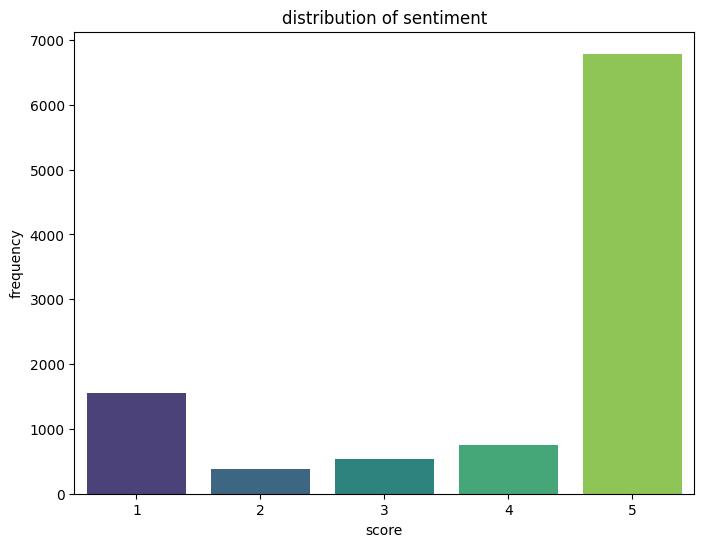

In [20]:
plt.figure(figsize=(8,6))
sns.countplot(data=data ,x='score', palette='viridis')
plt.title("distribution of sentiment")
plt.xlabel("score")
plt.ylabel("frequency")
plt.show()

In [21]:
print(f"score value count percentage distribution :\n {round(data["score"].value_counts()/data.shape[0]*100,2)}")#data.shape[0]= use kre hai rows check krne k liye kre hai

score value count percentage distribution :
 score
5    67.89
1    15.47
4     7.51
3     5.30
2     3.83
Name: count, dtype: float64


<Axes: ylabel='PErcentage distribution of score'>

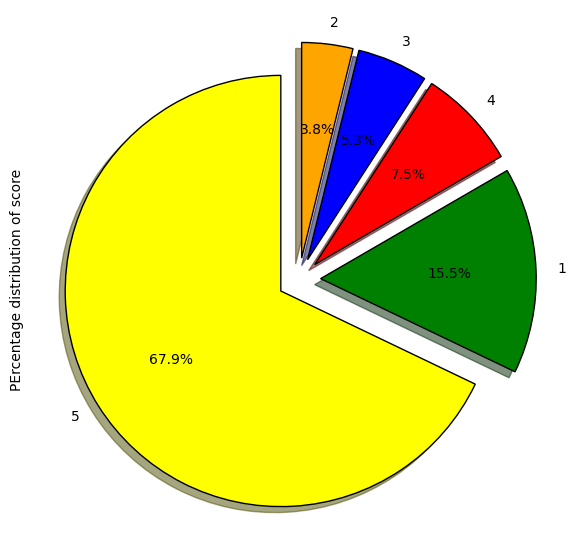

In [22]:
fig=plt.figure(figsize=(7,7))
colors=("yellow","green","red","blue","orange")
wp={"linewidth":1,"edgecolor":"black"}
tags=data["score"].value_counts()/data.shape[0]
explode=(0.1,0.1,0.1,0.1,0.1)
tags.plot(kind="pie",autopct="%1.1f%%",shadow=True,colors=colors,startangle=90,wedgeprops=wp,explode=explode,label="PErcentage distribution of score")

In [23]:
print(f"score value count percentage distribution :\n {round(data["score_review"].value_counts()/data.shape[0]*100,2)}")

score value count percentage distribution :
 score_review
positive    75.4
negative    19.3
neutral      5.3
Name: count, dtype: float64


/tmp/ipykernel_3019/3101526006.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=data ,x='score_review', palette='viridis')


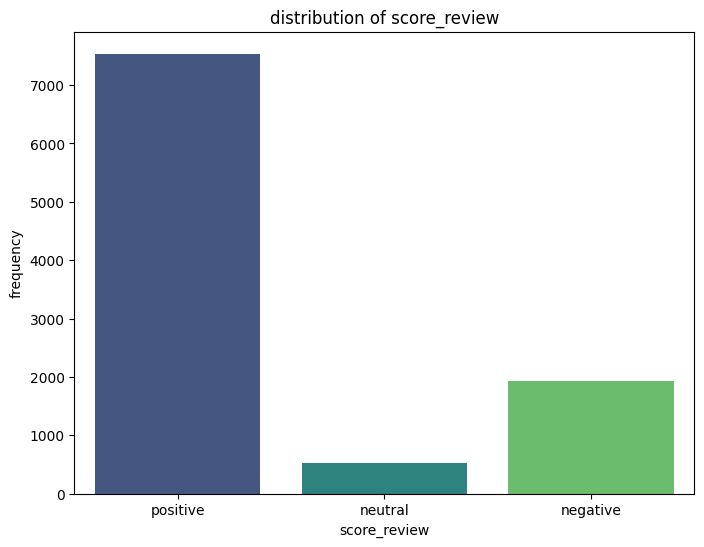

In [25]:
plt.figure(figsize=(8,6))
sns.countplot(data=data ,x='score_review', palette='viridis')
plt.title("distribution of score_review")
plt.xlabel("score_review")
plt.ylabel("frequency")
plt.show()

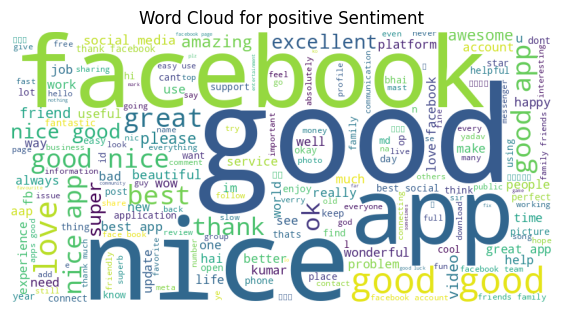

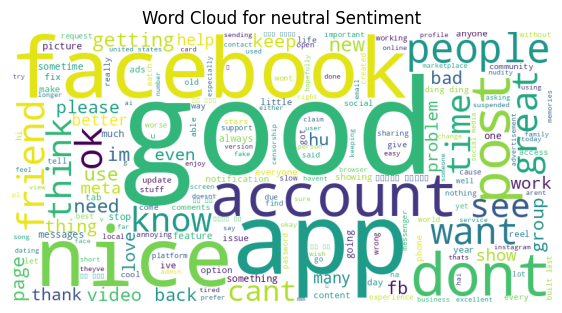

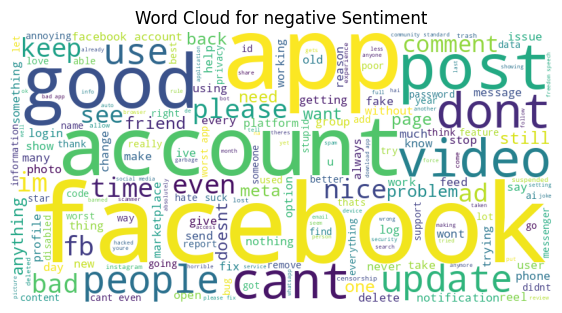

In [27]:
"""from wordcloud import wordcloud
for sentiment in data["score_review"].unique():
  text=" ".join(data[data["score_review"]==sentiment]["cleaned_content"])
  wordcloud=wordcloud(width=800,height=400,background_color="white").generate(text)

plt.figure(figsize=(8,8))
plt.imshow(wordcloud)
plt.title(f"wordcloud {sentiment}")
plt.show()
"""
#wordcloud---distribute words into psitive,negative and neutral

from wordcloud import WordCloud

for sentiment in data['score_review'].unique():
  text=' '.join(data[data['score_review']==sentiment]['cleaned_content'])
  wordcloud=WordCloud(width=800, height=400, background_color='white').generate(text)

  plt.figure(figsize=(7,5))
  plt.imshow(wordcloud)
  plt.title(f'Word Cloud for {sentiment} Sentiment')
  plt.axis('off')
  plt.show()


In [28]:
from sklearn.feature_extraction.text import TfidfVectorizer
tfidf=TfidfVectorizer(max_features=5000)
x = tfidf.fit_transform(data['cleaned_content']).toarray()
y = data["score_review"]

In [29]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score,classification_report
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [30]:
from sklearn.linear_model import LogisticRegression
lr_model=LogisticRegression()
lr_model.fit(x_train,y_train)

LogisticRegression()

In [31]:
lr_preds=lr_model.predict(x_test)
print("logistic regression")
print("accuracy: ",accuracy_score(y_test,lr_preds))

logistic regression
accuracy:  0.8125


In [32]:
from sklearn.naive_bayes import MultinomialNB
nb_model=MultinomialNB()
nb_model.fit(x_train,y_train)

MultinomialNB()

In [33]:
nb_preds=nb_model.predict(x_test)
print("naive bayes")
print("accuracy",accuracy_score(y_test,nb_preds))

naive bayes
accuracy 0.811


In [34]:
from sklearn.svm import SVC
svc_model=SVC()
svc_model.fit(x_train,y_train)


SVC()

In [35]:
svc_preds=svc_model.predict(x_test)
print("SVM")
print("accuracy",accuracy_score(y_test,svc_preds))

SVM
accuracy 0.8095


In [36]:
new_texts=["I love this!","it is ok","it is worst"]
new_texts_cleaned=[preprocess_text(text) for text in new_texts]
new_features=tfidf.transform(new_texts_cleaned).toarray()
predictions=lr_model.predict(new_features)
print(predictions)

['positive' 'positive' 'negative']
